# Decision Tree Classifier
> Multiclass Classification

> drug_class.ipynb


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [5]:
# encoding categorical features
gender_en = LabelEncoder()
bp_en = LabelEncoder()
chol_en = LabelEncoder()
class_en = LabelEncoder()


df['Gender'] = gender_en.fit_transform(df['Gender'])
df['Class'] = class_en.fit_transform(df['Class'])
df['Cholestrol'] = chol_en.fit_transform(df['Cholestrol'])
df['BloodPressure'] = bp_en.fit_transform(df['BloodPressure'])

In [7]:
# Features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

### Hyperparameter Tuning

In [13]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [3,5,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": [None,"sqrt","log2"],
    "max_leaf_nodes": [None,10,20,30]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv = 5,
    n_jobs=-1
)

grid.fit(x_train, y_train)

# best hyperparameters
print('Best Hyperparameters: ',grid.best_params_)
# best score
print('Best Score: ',grid.best_score_)
# best estimator
print('Best Model: ',grid.best_estimator_)

Best Hyperparameters:  {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best Score:  1.0
Best Model:  DecisionTreeClassifier(max_depth=5, random_state=42)


accuracy_score:  1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        24

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91





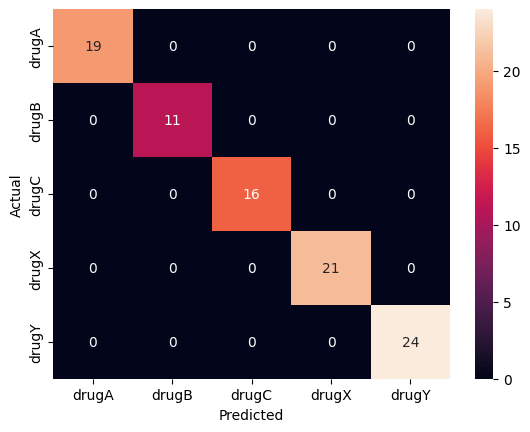

In [14]:
# training on best model
dt_best = grid.best_estimator_

dt_best .fit(x_train, y_train)
y_pred = dt_best.predict(x_test)
print('accuracy_score: ',accuracy_score(y_test, y_pred))
print('\n')
print(classification_report(y_test, y_pred))
print('\n')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, xticklabels=class_en.classes_, yticklabels=class_en.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance

In [18]:
importance_df = pd.DataFrame({
    'feature':x.columns,
    'importance':dt_best.feature_importances_
})

importance_df.sort_values(by = 'importance',ascending = False)

,feature,importance
2,BloodPressure,0.383480
0,Age,0.260509
4,Na_to_K,0.235005
3,Cholestrol,0.121006
1,Gender,0.000000


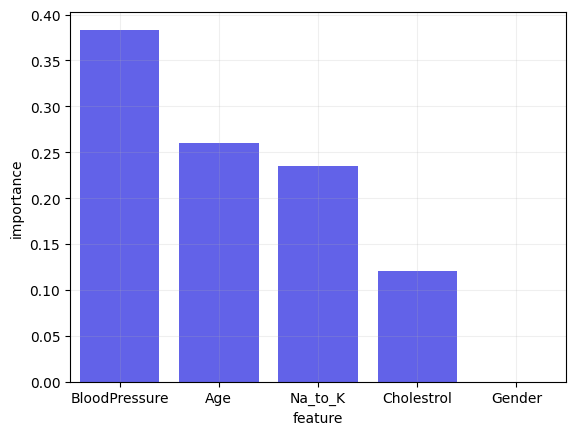

In [19]:
sns.barplot(
    data = importance_df.sort_values(by = 'importance',ascending = False),
    x = 'feature',
    y = 'importance',
    color = 'blue',
    alpha = 0.7
)
plt.grid(True, alpha = 0.2)
plt.show()

### Dimensionality Reduction
> keeping features <span style = 'color:orange'>above importance of 0.02</span>

In [22]:
selected_features = importance_df[importance_df['importance'] > 0.02]['feature']
selected_features

0              Age
2    BloodPressure
3       Cholestrol
4          Na_to_K
Name: feature, dtype: object

In [23]:
x_reduced = df[selected_features]
x_reduced.columns

Index(['Age', 'BloodPressure', 'Cholestrol', 'Na_to_K'], dtype='object')

In [24]:
# train test split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced,y,test_size=0.2, random_state=42)

In [25]:
# training model on reduced data
dt_reduded = DecisionTreeClassifier(random_state=42, **grid.best_params_)
dt_reduded.fit(x_trainr, y_trainr)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [26]:
y_Pred = dt_reduded.predict(x_testr)
print('accuracy_score: ',accuracy_score(y_testr, y_Pred))

accuracy_score:  1.0
